# Análisis Exhaustivo de Teoría Musical del Dataset

Dataset: `dataset_with_jsymbolic.parquet`  
Incluye 11 features de jSymbolic + progresiones de acordes en formato pitch-class vectors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
df = pd.read_parquet('dataset_with_jsymbolic.parquet')
print(f'Shape: {df.shape}')
print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Shape: (877342, 15)
Filas: 877,342
Columnas: 15
Memoria: 838.09 MB


In [3]:
# Parsear chords y vectors (vienen como strings en formato JSON)
df['chords_parsed'] = df['chords'].apply(json.loads)
df['vectors_parsed'] = df['vectors'].apply(json.loads)

print('Ejemplo de una fila:')
row = df.iloc[0]
print(f'  n_chords: {row["n_chords"]}')
print(f'  chords (primeros 5): {row["chords_parsed"][:5]}')
print(f'  vectors (primeros 2): {row["vectors_parsed"][:2]}')

Ejemplo de una fila:
  n_chords: 17
  chords (primeros 5): ['F', 'C', 'E7', 'Am', 'C']
  vectors (primeros 2): [[1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0], [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]]


---
## 1. Distribución de longitud de progresiones

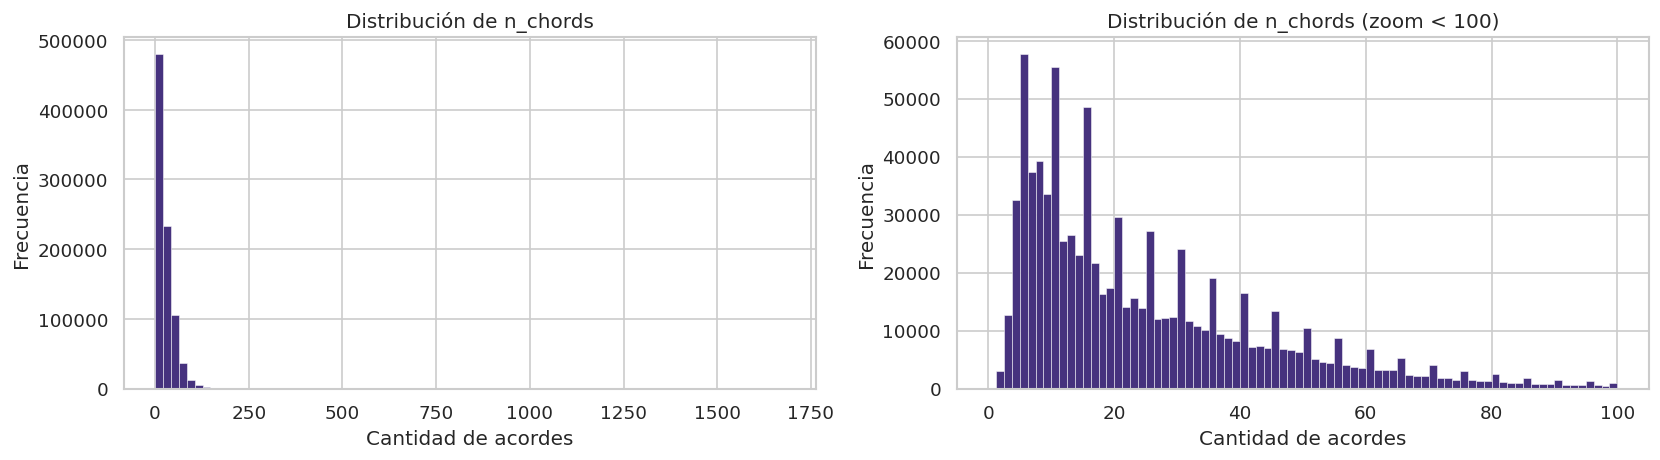

Estadísticos de n_chords:
count    877342.000000
mean         26.409471
std          26.045247
min           1.000000
25%          10.000000
50%          19.000000
75%          36.000000
max        1679.000000

Percentiles:
   1%: 3
   5%: 4
  10%: 6
  25%: 10
  50%: 19
  75%: 36
  90%: 56
  95%: 70
  99%: 107


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['n_chords'], bins=80, edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribución de n_chords')
axes[0].set_xlabel('Cantidad de acordes')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['n_chords'], bins=80, range=(0, 100), edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribución de n_chords (zoom < 100)')
axes[1].set_xlabel('Cantidad de acordes')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('Estadísticos de n_chords:')
print(df['n_chords'].describe().to_string())
print(f'\nPercentiles:')
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  {p:2d}%: {df["n_chords"].quantile(p/100):.0f}')

---
## 2. Análisis de Acordes

In [5]:
# Recolectar todos los acordes del dataset
all_chords = []
for chords in df['chords_parsed']:
    all_chords.extend(chords)

total_chords = len(all_chords)
unique_chords = len(set(all_chords))
print(f'Total de acordes en el dataset: {total_chords:,}')
print(f'Acordes únicos: {unique_chords:,}')
print(f'Vocabulario armónico: {unique_chords} tipos de acordes distintos')

Total de acordes en el dataset: 23,170,138
Acordes únicos: 4,151
Vocabulario armónico: 4151 tipos de acordes distintos


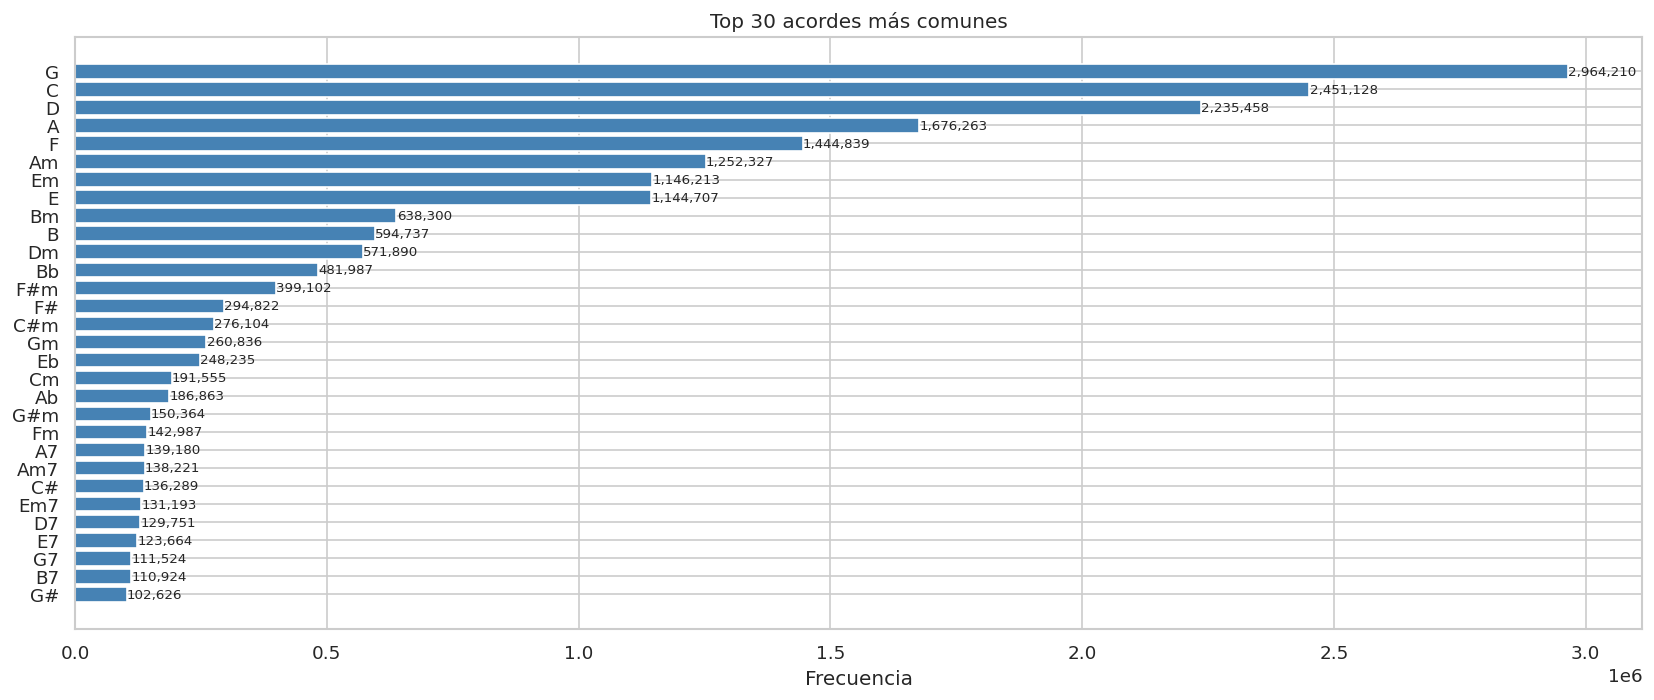

Top 10 representa: 67.1% del total
Top 20 representa: 80.3% del total


In [6]:
chord_counter = Counter(all_chords)
top_n = 30
most_common = chord_counter.most_common(top_n)
chords_names, chords_counts = zip(*most_common)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(range(len(chords_names)), chords_counts, color='steelblue')
ax.set_yticks(range(len(chords_names)))
ax.set_yticklabels(chords_names)
ax.invert_yaxis()
ax.set_xlabel('Frecuencia')
ax.set_title(f'Top {top_n} acordes más comunes')

for bar, count in zip(bars, chords_counts):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'Top 10 representa: {sum(chords_counts[:10])/total_chords*100:.1f}% del total')
print(f'Top 20 representa: {sum(chords_counts[:20])/total_chords*100:.1f}% del total')

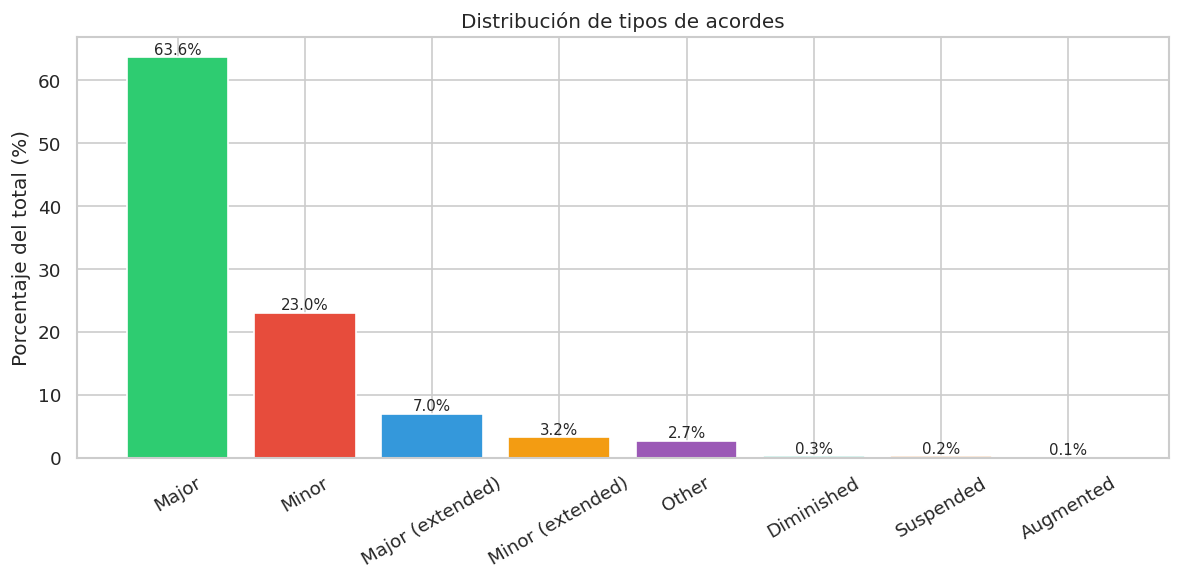


Distribución detallada:
  Major               : 14,743,549 (63.63%)
  Minor               : 5,336,431 (23.03%)
  Major (extended)    : 1,612,285 ( 6.96%)
  Minor (extended)    :  746,762 ( 3.22%)
  Other               :  616,187 ( 2.66%)
  Diminished          :   59,533 ( 0.26%)
  Suspended           :   39,969 ( 0.17%)
  Augmented           :   15,422 ( 0.07%)


In [7]:
# Clasificar acordes por tipo armónico
import re

def classify_chord_type(chord):
    """Clasifica un acorde en categorías de teoría musical."""
    if '/' in chord:
        chord = chord.split('/')[0]
    
    # Remover nota fundamental
    match = re.match(r'^[A-G][#b]?(.*)$', chord)
    if not match:
        return 'unknown'
    suffix = match.group(1)
    
    if not suffix or suffix == '':
        return 'Major'
    if suffix == 'm' or suffix == 'min':
        return 'Minor'
    if suffix == 'dim' or suffix == '°':
        return 'Diminished'
    if suffix == 'aug' or suffix == '+':
        return 'Augmented'
    if 'dim' in suffix:
        return 'Diminished'
    if 'aug' in suffix:
        return 'Augmented'
    if suffix.startswith('maj') or 'maj' in suffix:
        return 'Major (extended)'
    if suffix.startswith('m') or 'min' in suffix:
        return 'Minor (extended)'
    if any(s in suffix for s in ['7', '9', '11', '13']):
        if suffix.startswith('m') or 'min' in suffix:
            return 'Minor (extended)'
        return 'Major (extended)'
    if suffix in ['sus2', 'sus4', 'sus']:
        return 'Suspended'
    if 'sus' in suffix:
        return 'Suspended'
    if suffix == '6' or suffix == 'm6':
        return 'Sixth'
    if 'add' in suffix:
        return 'Added tone'
    return 'Other'

chord_types = [classify_chord_type(ch) for ch in all_chords]
type_counter = Counter(chord_types)

fig, ax = plt.subplots(figsize=(10, 5))
types, counts = zip(*type_counter.most_common())
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e', '#95a5a6']
bars = ax.bar(types, [c/total_chords*100 for c in counts], color=colors[:len(types)])
ax.set_ylabel('Porcentaje del total (%)')
ax.set_title('Distribución de tipos de acordes')
ax.tick_params(axis='x', rotation=30)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{count/total_chords*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nDistribución detallada:')
for t, c in type_counter.most_common():
    print(f'  {t:20s}: {c:>8,} ({c/total_chords*100:5.2f}%)')

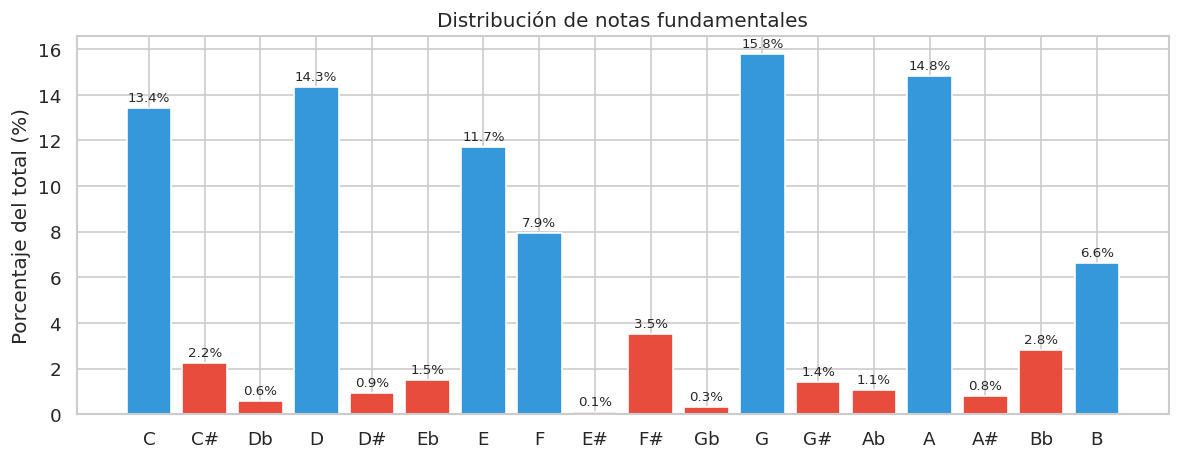


Frecuencia por nota fundamental:
    C: 3,108,938 (13.42%)
   C#:  514,827 ( 2.22%)
   Db:  137,177 ( 0.59%)
    D: 3,321,899 (14.34%)
   D#:  218,917 ( 0.94%)
   Eb:  350,076 ( 1.51%)
    E: 2,715,256 (11.72%)
    F: 1,840,052 ( 7.94%)
   E#:   25,284 ( 0.11%)
   F#:  817,530 ( 3.53%)
   Gb:   73,185 ( 0.32%)
    G: 3,655,790 (15.78%)
   G#:  327,692 ( 1.41%)
   Ab:  248,018 ( 1.07%)
    A: 3,430,485 (14.81%)
   A#:  183,686 ( 0.79%)
   Bb:  651,642 ( 2.81%)
    B: 1,530,288 ( 6.60%)


In [8]:
# Distribución de notas fundamentales (root notes)
ROOT_PITCH = {'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3, 'E': 4,
              'Fb': 4, 'E#': 5, 'F': 5, 'F#': 6, 'Gb': 6, 'G': 7,
              'G#': 8, 'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11, 'Cb': 11}

NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def extract_root(chord):
    if '/' in chord:
        chord = chord.split('/')[0]
    match = re.match(r'^([A-G][#b]?)(.*)$', chord)
    if match:
        root = match.group(1)
        root = root.replace('s', '#')
        if root in ROOT_PITCH:
            return root, ROOT_PITCH[root]
    return None, None

roots = []
for ch in all_chords:
    root_name, root_pc = extract_root(ch)
    if root_name:
        roots.append(root_name)

root_counter = Counter(roots)

fig, ax = plt.subplots(figsize=(10, 4))
root_names_sorted = sorted(root_counter.keys(), key=lambda x: ROOT_PITCH.get(x.replace('s','#'), 0))
root_values = [root_counter[r] for r in root_names_sorted]

colors_roots = ['#3498db' if '#' not in r and 'b' not in r else '#e74c3c' for r in root_names_sorted]
bars = ax.bar(root_names_sorted, [v/total_chords*100 for v in root_values], color=colors_roots)
ax.set_ylabel('Porcentaje del total (%)')
ax.set_title('Distribución de notas fundamentales')

for bar, v in zip(bars, root_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v/total_chords*100:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\nFrecuencia por nota fundamental:')
for r in root_names_sorted:
    v = root_counter[r]
    print(f'  {r:>3s}: {v:>8,} ({v/total_chords*100:5.2f}%)')

---
## 3. Análisis de Pitch-Class Sets

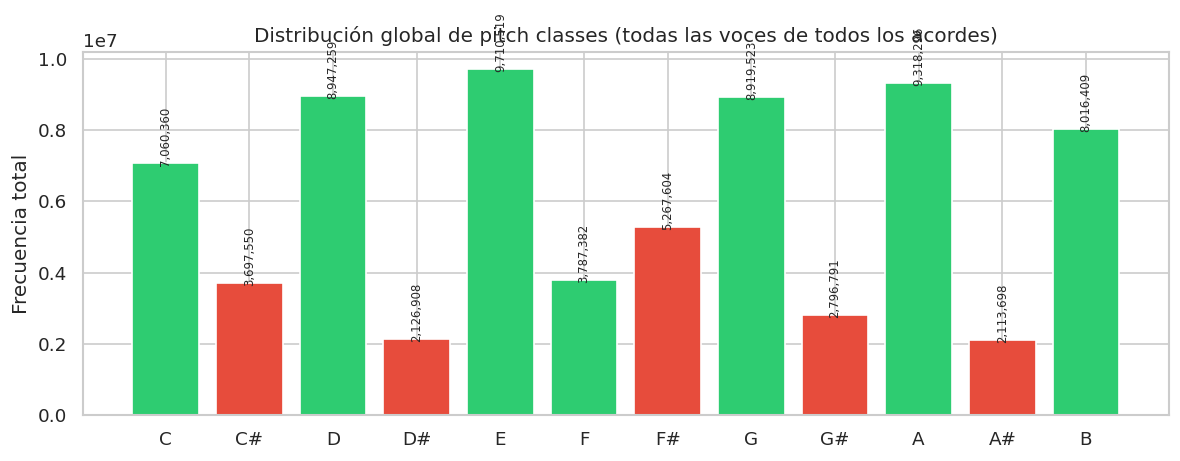


Frecuencia por pitch class:
    C:  7,060,360 ( 9.84%)
   C#:  3,697,550 ( 5.15%)
    D:  8,947,259 (12.47%)
   D#:  2,126,908 ( 2.96%)
    E:  9,710,519 (13.53%)
    F:  3,787,382 ( 5.28%)
   F#:  5,267,604 ( 7.34%)
    G:  8,919,523 (12.43%)
   G#:  2,796,791 ( 3.90%)
    A:  9,318,296 (12.98%)
   A#:  2,113,698 ( 2.95%)
    B:  8,016,409 (11.17%)


In [9]:
# Distribución global de pitch classes (suma de todos los vectores)
pitch_class_sum = np.zeros(12)
for vectors in df['vectors_parsed']:
    for vec in vectors:
        pitch_class_sum += np.array(vec)

fig, ax = plt.subplots(figsize=(10, 4))
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
colors_pc = ['#2ecc71' if i in [0, 2, 4, 5, 7, 9, 11] else '#e74c3c' for i in range(12)]
bars = ax.bar(NOTE_NAMES, pitch_class_sum, color=colors_pc)
ax.set_ylabel('Frecuencia total')
ax.set_title('Distribución global de pitch classes (todas las voces de todos los acordes)')

for bar, v in zip(bars, pitch_class_sum):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{v:,.0f}', ha='center', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

print('\nFrecuencia por pitch class:')
for i, name in enumerate(NOTE_NAMES):
    print(f'  {name:>3s}: {pitch_class_sum[i]:>10,.0f} ({pitch_class_sum[i]/pitch_class_sum.sum()*100:5.2f}%)')

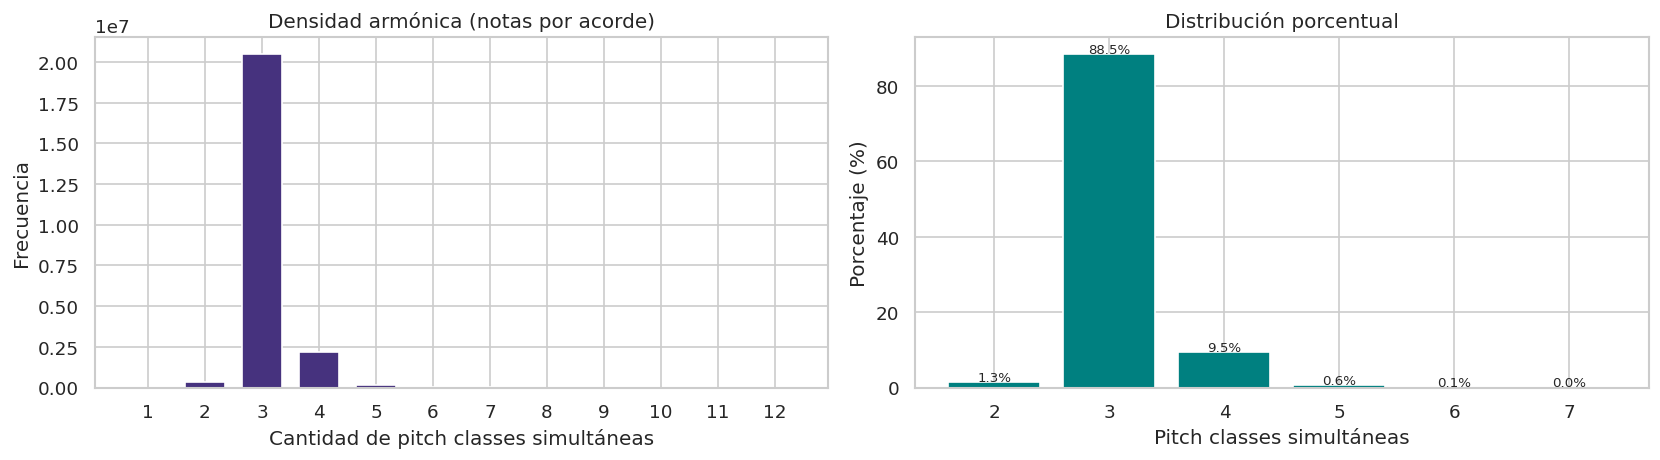


Pitch classes por acorde:
  Media: 3.10
  Mediana: 3.0
  Min: 2
  Max: 7


In [10]:
# Número de pitch classes simultáneas (densidad armónica)
n_pcs_per_chord = []
for vectors in df['vectors_parsed']:
    for vec in vectors:
        n_pcs_per_chord.append(sum(vec))

pc_counter = Counter(n_pcs_per_chord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(n_pcs_per_chord, bins=range(1, 14), align='left', rwidth=0.7, edgecolor='white')
axes[0].set_xlabel('Cantidad de pitch classes simultáneas')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Densidad armónica (notas por acorde)')
axes[0].set_xticks(range(1, 13))

pcs = sorted(pc_counter.keys())
vals = [pc_counter[p] for p in pcs]
axes[1].bar([str(p) for p in pcs], [v/len(n_pcs_per_chord)*100 for v in vals], 
           color='teal', edgecolor='white')
axes[1].set_xlabel('Pitch classes simultáneas')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Distribución porcentual')

for i, (p, v) in enumerate(zip(pcs, vals)):
    axes[1].text(i, v/len(n_pcs_per_chord)*100 + 0.3, f'{v/len(n_pcs_per_chord)*100:.1f}%',
                ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nPitch classes por acorde:')
print(f'  Media: {np.mean(n_pcs_per_chord):.2f}')
print(f'  Mediana: {np.median(n_pcs_per_chord):.1f}')
print(f'  Min: {min(n_pcs_per_chord)}')
print(f'  Max: {max(n_pcs_per_chord)}')

Extrayendo vectores de acordes individuales para PCA...
Vectores individuales extraídos: 1,321,633

Varianza explicada por componente:
  PC1: 0.2522 (25.22%)
  PC2: 0.2414 (24.14%)
  PC3: 0.1345 (13.45%)
  Total 3 componentes: 62.80%


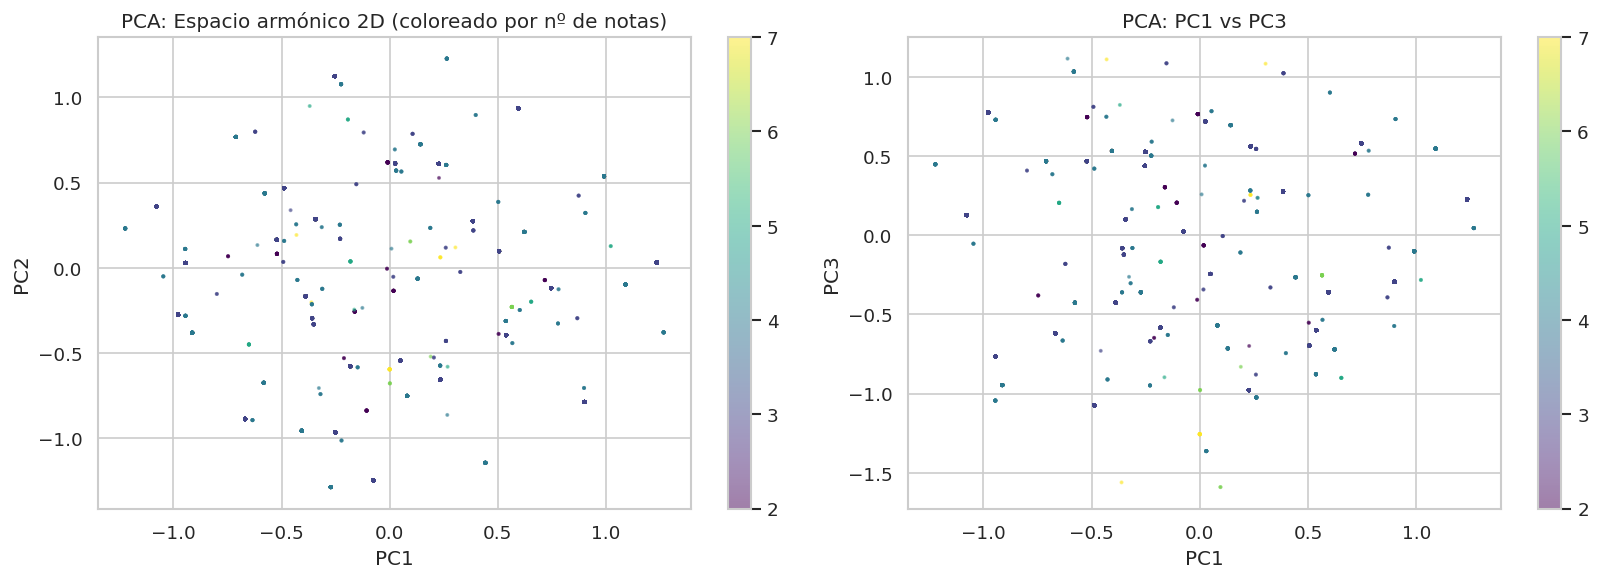


Cargas de PC1 (contribución por pitch class):
    C: -0.3305
   C#: -0.1970
    D: +0.3959
   D#: +0.0343
    E: -0.2444
    F: -0.1449
   F#: +0.0312
    G: +0.3667
   G#: -0.0012
    A: -0.4571
   A#: +0.0290
    B: +0.5178


In [11]:
# PCA de los vectores de acordes individuales para visualizar el espacio armónico
print('Extrayendo vectores de acordes individuales para PCA...')

# Muestrear para no saturar memoria
sample_size = min(50000, len(df))
df_sample = df.sample(sample_size, random_state=42)

all_individual_vectors = []
for vectors in df_sample['vectors_parsed']:
    for vec in vectors:
        all_individual_vectors.append(vec)

X = np.array(all_individual_vectors)
print(f'Vectores individuales extraídos: {len(X):,}')

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print(f'\nVarianza explicada por componente:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.2f}%)')
print(f'  Total 3 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(X_pca[:10000, 0], X_pca[:10000, 1], 
                         c=np.sum(X[:10000], axis=1), cmap='viridis', 
                         alpha=0.5, s=2)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA: Espacio armónico 2D (coloreado por nº de notas)')
plt.colorbar(scatter, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:10000, 0], X_pca[:10000, 2],
                          c=np.sum(X[:10000], axis=1), cmap='viridis',
                          alpha=0.5, s=2)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC3')
axes[1].set_title('PCA: PC1 vs PC3')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

# Cargas de componentes
print('\nCargas de PC1 (contribución por pitch class):')
for i, name in enumerate(NOTE_NAMES):
    print(f'  {name:>3s}: {pca.components_[0][i]:+.4f}')

---
## 4. Análisis de Features de jSymbolic

In [12]:
FEATURES = [
    'Vertical_Minor_Seconds', 'Vertical_Tritones', 'Vertical_Sevenths',
    'Vertical_Dissonance_Ratio', 'Standard_Triads', 'Seventh_Chords',
    'Non-Standard_Chords', 'Complex_Chords',
    'Distance_Between_Two_Most_Common_Vertical_Intervals',
    'Prevalence_Ratio_of_Two_Most_Common_Vertical_Intervals',
    'Variability_of_Number_of_Simultaneous_Pitch_Classes'
]

FEATURE_LABELS = {
    'Vertical_Minor_Seconds': 'Segundas menores (dis. fuerte)',
    'Vertical_Tritones': 'Tritonos',
    'Vertical_Sevenths': 'Séptimas',
    'Vertical_Dissonance_Ratio': 'Ratio de disonancia vertical',
    'Standard_Triads': 'Tríadas estándar',
    'Seventh_Chords': 'Acordes de séptima',
    'Non-Standard_Chords': 'Acordes no estándar',
    'Complex_Chords': 'Acordes complejos',
    'Distance_Between_Two_Most_Common_Vertical_Intervals': 'Dist. entre intervalos más comunes',
    'Prevalence_Ratio_of_Two_Most_Common_Vertical_Intervals': 'Ratio de prevalencia de intervalos',
    'Variability_of_Number_of_Simultaneous_Pitch_Classes': 'Variabilidad de PC simultáneas'
}

print(f'Estadísticos descriptivos de features jSymbolic:')
print(df[FEATURES].describe().round(4).to_string())

Estadísticos descriptivos de features jSymbolic:
       Vertical_Minor_Seconds  Vertical_Tritones  Vertical_Sevenths  Vertical_Dissonance_Ratio  Standard_Triads  Seventh_Chords  Non-Standard_Chords  Complex_Chords  Distance_Between_Two_Most_Common_Vertical_Intervals  Prevalence_Ratio_of_Two_Most_Common_Vertical_Intervals  Variability_of_Number_of_Simultaneous_Pitch_Classes
count             877342.0000        877342.0000        877342.0000                877342.0000      877342.0000     877342.0000          877342.0000     877342.0000                                          877342.0000                                             877342.0000                                          877342.0000
mean                   0.0047             0.0113             0.0041                     0.0565           0.8516          0.0967               0.0367          0.0086                                               1.4136                                                  0.7513                        

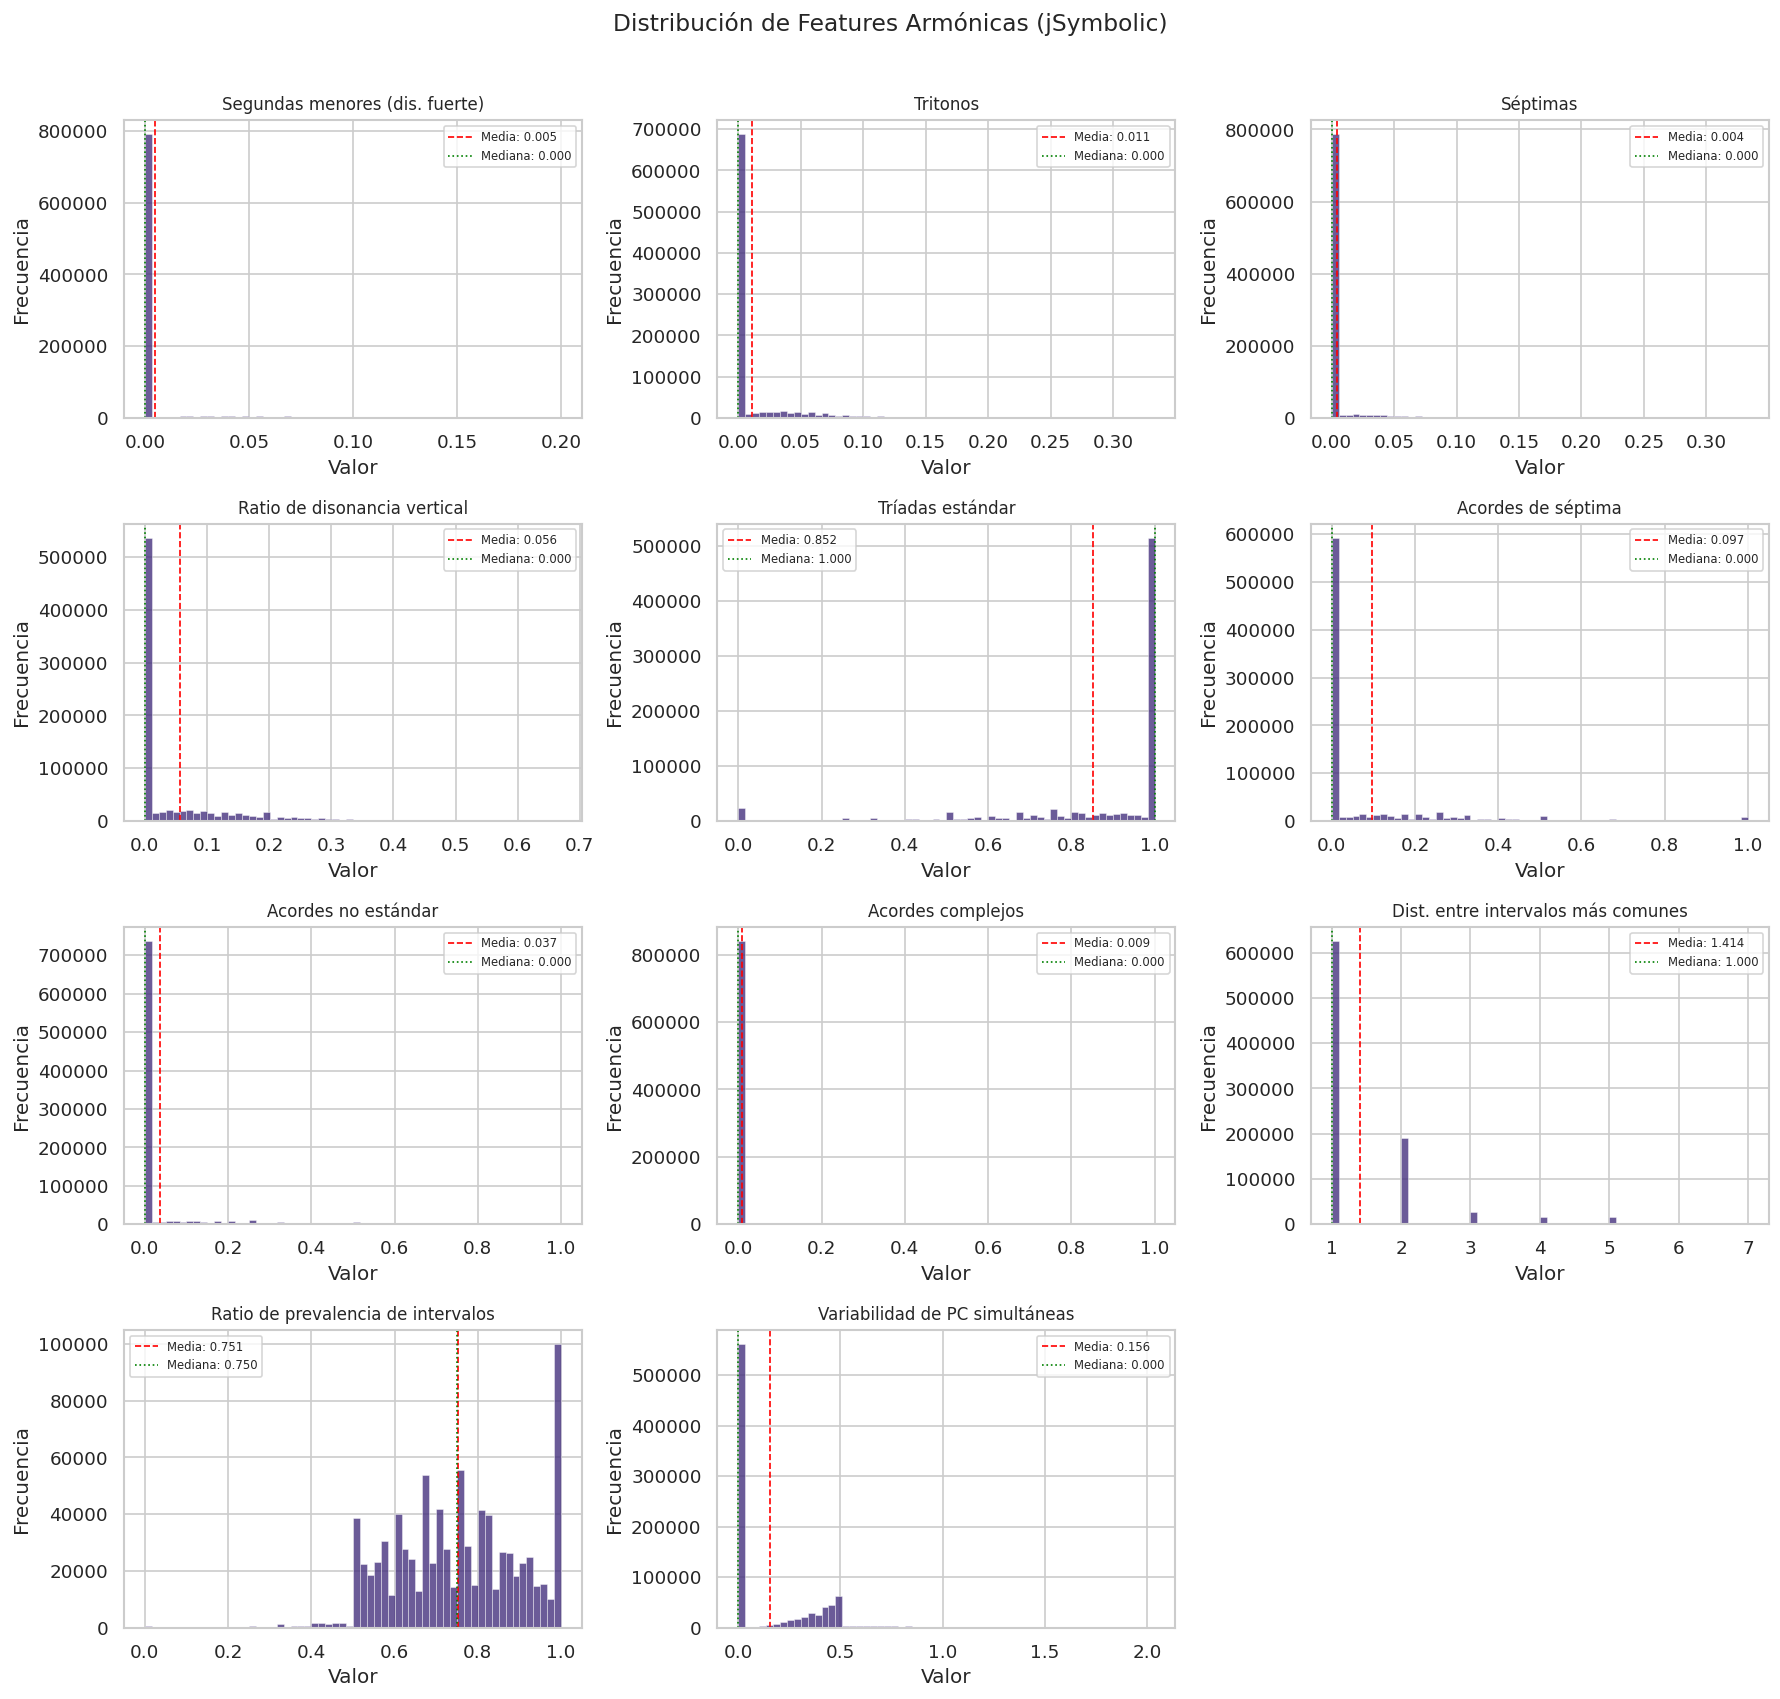

In [13]:
# Histogramas de cada feature
n_feats = len(FEATURES)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df[feat].dropna(), bins=60, edgecolor='white', linewidth=0.3, alpha=0.8)
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=10)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    
    # Estadísticos
    mean_val = df[feat].mean()
    median_val = df[feat].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Media: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle=':', linewidth=1, label=f'Mediana: {median_val:.3f}')
    ax.legend(fontsize=7)

for i in range(n_feats, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribución de Features Armónicas (jSymbolic)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

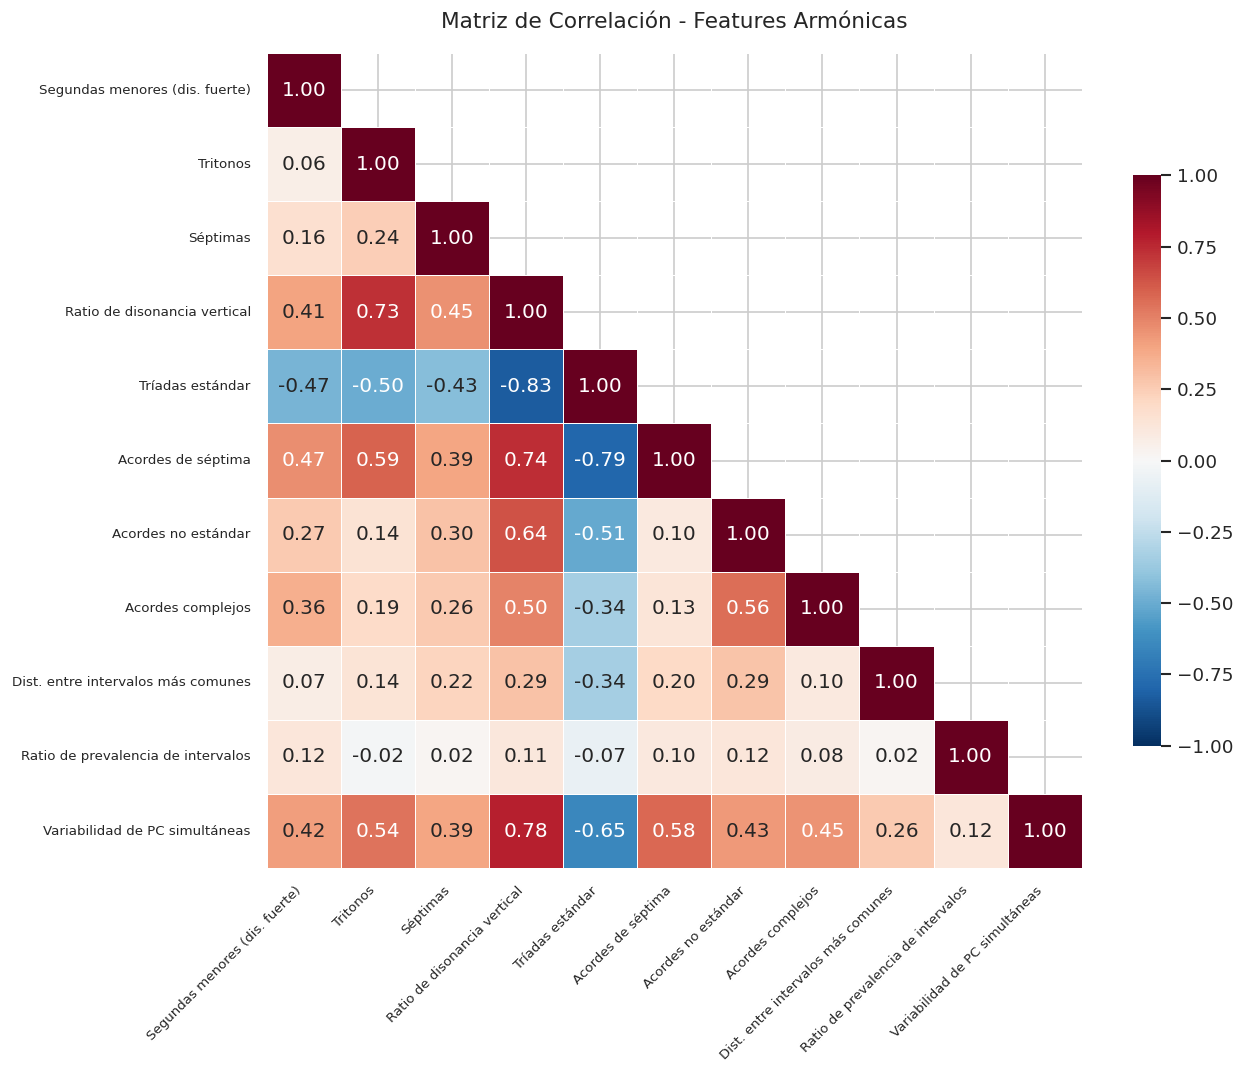

Correlaciones más fuertes (|r| > 0.5):
  Tritonos                                 vs Ratio de disonancia vertical       : r = +0.730
  Tritonos                                 vs Acordes de séptima                 : r = +0.589
  Tritonos                                 vs Variabilidad de PC simultáneas     : r = +0.543
  Ratio de disonancia vertical             vs Tríadas estándar                   : r = -0.834
  Ratio de disonancia vertical             vs Acordes de séptima                 : r = +0.740
  Ratio de disonancia vertical             vs Acordes no estándar                : r = +0.640
  Ratio de disonancia vertical             vs Variabilidad de PC simultáneas     : r = +0.781
  Tríadas estándar                         vs Acordes de séptima                 : r = -0.790
  Tríadas estándar                         vs Acordes no estándar                : r = -0.513
  Tríadas estándar                         vs Variabilidad de PC simultáneas     : r = -0.654
  Acordes de séptima 

In [14]:
# Matriz de correlación entre features
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
ax.set_xticklabels([FEATURE_LABELS.get(c, c) for c in corr.columns], 
                   rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([FEATURE_LABELS.get(c, c) for c in corr.columns], 
                   rotation=0, fontsize=8)
ax.set_title('Matriz de Correlación - Features Armónicas', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Mostrar correlaciones más fuertes
print('Correlaciones más fuertes (|r| > 0.5):')
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {FEATURE_LABELS[FEATURES[i]]:40s} vs {FEATURE_LABELS[FEATURES[j]]:35s}: r = {r:+.3f}')

Aplicando PCA a las features jSymbolic...


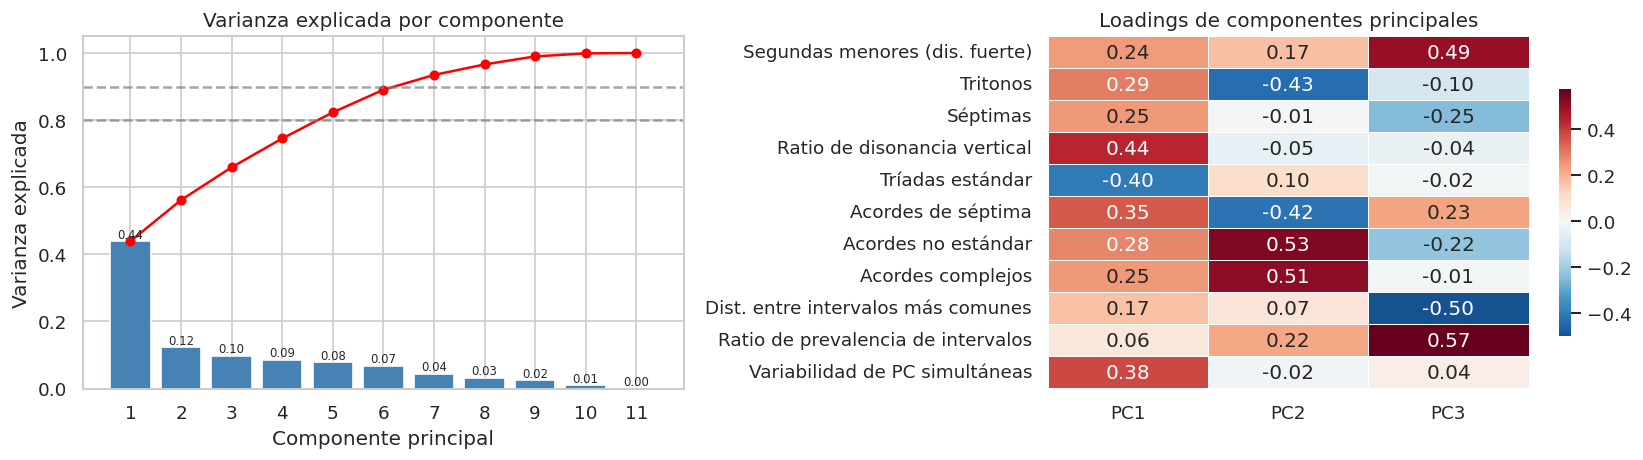


Componentes necesarios para:
  80% varianza: 5
  90% varianza: 7
  95% varianza: 8


In [15]:
# PCA de las features jSymbolic
print('Aplicando PCA a las features jSymbolic...')

X_feat = StandardScaler().fit_transform(df[FEATURES])
pca_feat = PCA().fit(X_feat)

cum_var = np.cumsum(pca_feat.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(FEATURES)+1), pca_feat.explained_variance_ratio_, 
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(FEATURES)+1), cum_var, 'ro-', markersize=5)
axes[0].axhline(0.8, color='gray', linestyle='--', alpha=0.7)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xticks(range(1, len(FEATURES)+1))

for i, (var, cum) in enumerate(zip(pca_feat.explained_variance_ratio_, cum_var)):
    axes[0].text(i+1, var + 0.01, f'{var:.2f}', ha='center', fontsize=7)

# Loadings
loadings = pd.DataFrame(
    pca_feat.components_[:3].T,
    index=[FEATURE_LABELS.get(f, f) for f in FEATURES],
    columns=['PC1', 'PC2', 'PC3']
)

sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], linewidths=0.5, cbar_kws={'shrink': 0.7})
axes[1].set_title('Loadings de componentes principales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'\nComponentes necesarios para:')
print(f'  80% varianza: {np.argmax(cum_var >= 0.8) + 1}')
print(f'  90% varianza: {np.argmax(cum_var >= 0.9) + 1}')
print(f'  95% varianza: {np.argmax(cum_var >= 0.95) + 1}')

---
## 5. Relación entre Features y Longitud de Progresión

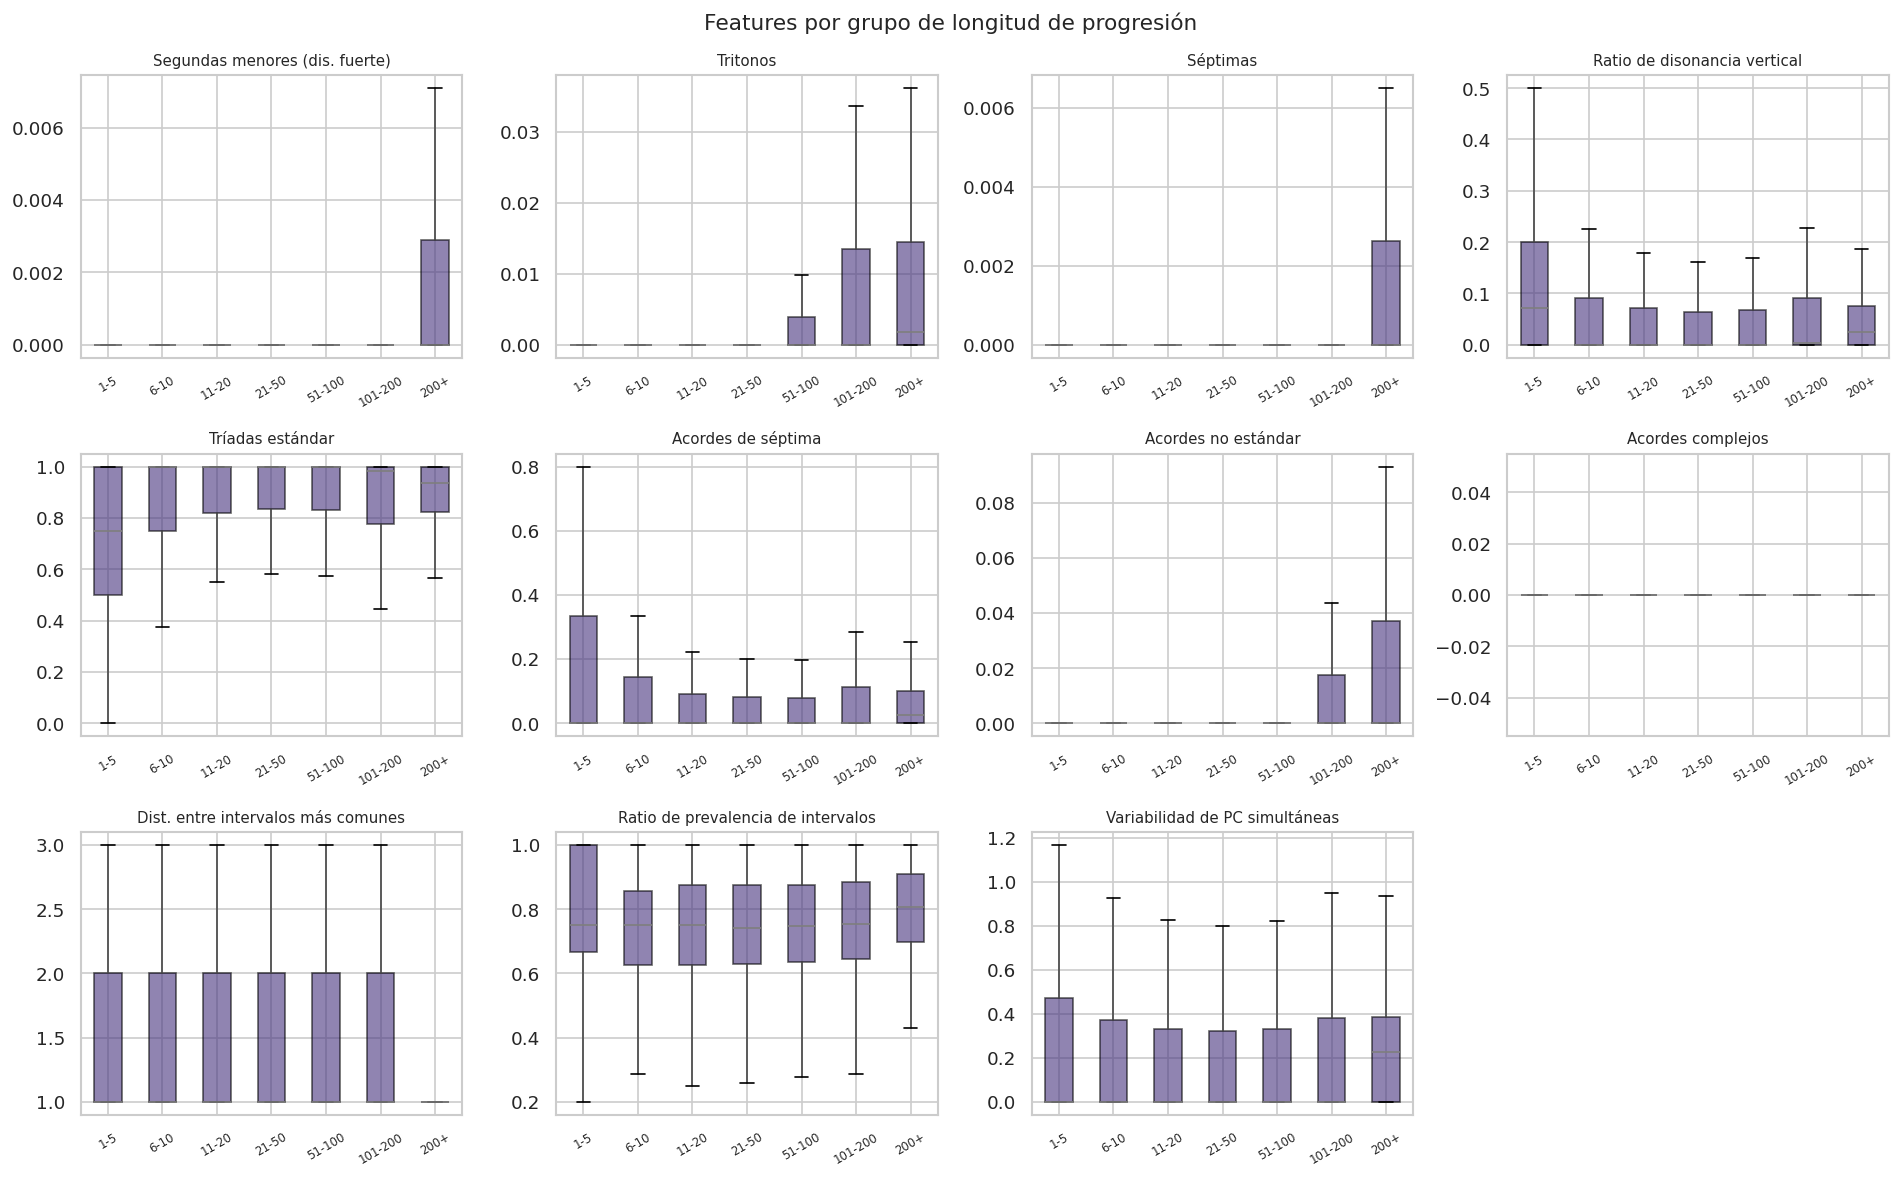

Correlación de features con n_chords:
  Tríadas estándar                             : r = +0.0743
  Ratio de prevalencia de intervalos           : r = -0.0025
  Variabilidad de PC simultáneas               : r = -0.0169
  Dist. entre intervalos más comunes           : r = -0.0216
  Acordes complejos                            : r = -0.0280
  Tritonos                                     : r = -0.0309
  Séptimas                                     : r = -0.0387
  Acordes no estándar                          : r = -0.0419
  Segundas menores (dis. fuerte)               : r = -0.0514
  Ratio de disonancia vertical                 : r = -0.0632
  Acordes de séptima                           : r = -0.0642


In [16]:
# Discretizar n_chords en grupos
df['prog_group'] = pd.cut(df['n_chords'], 
    bins=[0, 5, 10, 20, 50, 100, 200, np.inf],
    labels=['1-5', '6-10', '11-20', '21-50', '51-100', '101-200', '200+'])

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    df.boxplot(column=feat, by='prog_group', ax=ax, showfliers=False,
               patch_artist=True, boxprops=dict(alpha=0.6))
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=7)

for i in range(len(FEATURES), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Features por grupo de longitud de progresión', fontsize=13)
plt.tight_layout()
plt.show()

# Correlación con n_chords
print('Correlación de features con n_chords:')
corr_with_len = df[FEATURES + ['n_chords']].corr()['n_chords'].drop('n_chords')
for feat, r in corr_with_len.sort_values(ascending=False).items():
    print(f'  {FEATURE_LABELS.get(feat, feat):45s}: r = {r:+.4f}')

---
## 6. Análisis de Disonancia y Complejidad

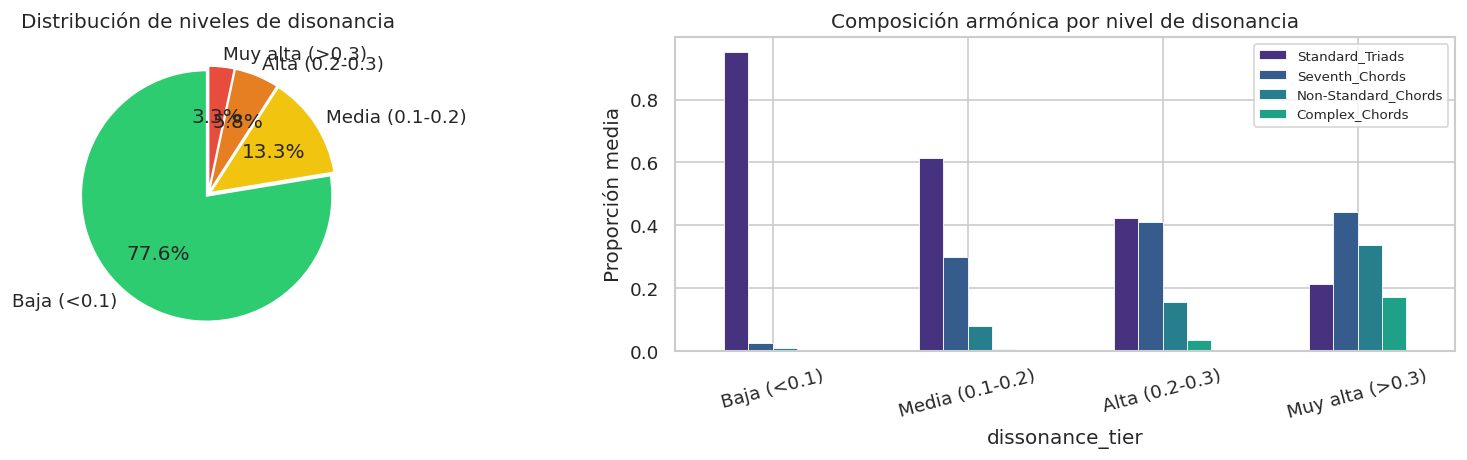


Composición armónica por nivel de disonancia:
                 Standard_Triads  Seventh_Chords  Non-Standard_Chords  Complex_Chords
dissonance_tier                                                                      
Baja (<0.1)               0.9515          0.0238               0.0076          0.0001
Media (0.1-0.2)           0.6148          0.2993               0.0798          0.0055
Alta (0.2-0.3)            0.4242          0.4117               0.1568          0.0357
Muy alta (>0.3)           0.2117          0.4422               0.3362          0.1725


In [17]:
# Crear categorías de disonancia
df['dissonance_tier'] = pd.cut(df['Vertical_Dissonance_Ratio'],
    bins=[-np.inf, 0.1, 0.2, 0.3, np.inf],
    labels=['Baja (<0.1)', 'Media (0.1-0.2)', 'Alta (0.2-0.3)', 'Muy alta (>0.3)'])

dissonance_dist = df['dissonance_tier'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_tier = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
axes[0].pie(dissonance_dist.values, labels=dissonance_dist.index, autopct='%1.1f%%',
           colors=colors_tier, startangle=90, explode=[0.02]*4)
axes[0].set_title('Distribución de niveles de disonancia')

# Relación entre disonancia y otros features
tier_means = df.groupby('dissonance_tier', observed=True)[FEATURES].mean()

sub_feats = ['Standard_Triads', 'Seventh_Chords', 'Non-Standard_Chords', 'Complex_Chords']
tier_means[sub_feats].plot(kind='bar', ax=axes[1], edgecolor='white', linewidth=0.5)
axes[1].set_title('Composición armónica por nivel de disonancia')
axes[1].set_ylabel('Proporción media')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nComposición armónica por nivel de disonancia:')
print(tier_means[sub_feats].round(4).to_string())

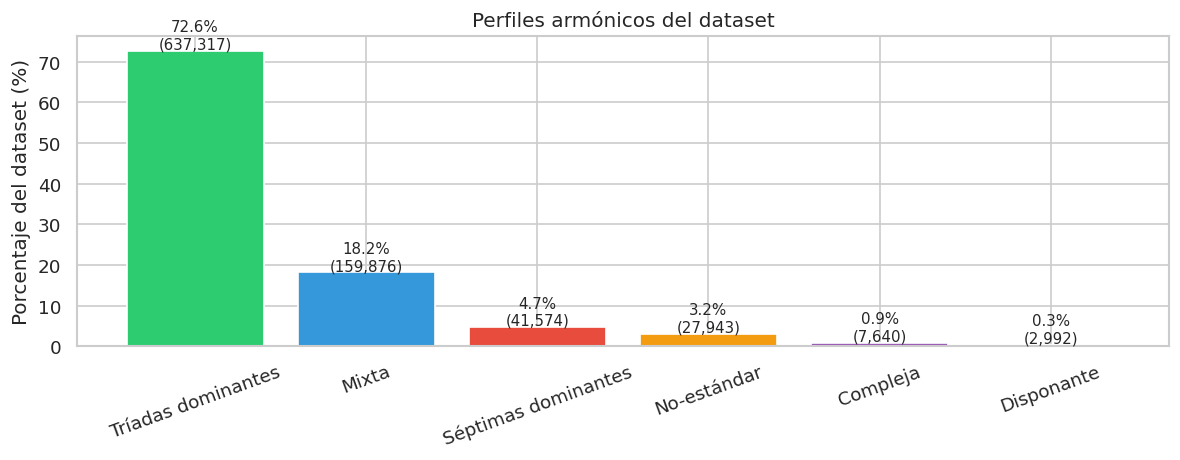


Distribución de perfiles armónicos:
  Tríadas dominantes       :  637,317 (72.64%)
  Mixta                    :  159,876 (18.22%)
  Séptimas dominantes      :   41,574 ( 4.74%)
  No-estándar              :   27,943 ( 3.18%)
  Compleja                 :    7,640 ( 0.87%)
  Disponante               :    2,992 ( 0.34%)


In [18]:
# Clasificar progresiones por tipo armónico dominante
def classify_progression(row):
    """Clasifica una progresión según su perfil armónico."""
    if row['Standard_Triads'] > 0.8:
        return 'Tríadas dominantes'
    elif row['Complex_Chords'] > 0.3:
        return 'Compleja'
    elif row['Seventh_Chords'] > 0.5:
        return 'Séptimas dominantes'
    elif row['Non-Standard_Chords'] > 0.3:
        return 'No-estándar'
    elif row['Vertical_Dissonance_Ratio'] > 0.3:
        return 'Disponante'
    else:
        return 'Mixta'

df['harmonic_profile'] = df.apply(classify_progression, axis=1)
profile_dist = df['harmonic_profile'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(profile_dist.index, profile_dist.values / len(df) * 100, 
             color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'],
             edgecolor='white')
ax.set_ylabel('Porcentaje del dataset (%)')
ax.set_title('Perfiles armónicos del dataset')
ax.tick_params(axis='x', rotation=20)

for bar, v in zip(bars, profile_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v/len(df)*100:.1f}%\n({v:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nDistribución de perfiles armónicos:')
for profile, count in profile_dist.items():
    print(f'  {profile:25s}: {count:>8,} ({count/len(df)*100:5.2f}%)')

---
## 7. Análisis de Intervalos Verticales

Distancia entre los 2 intervalos más comunes:
  Media: 1.414
  Mediana: 1.000
  Los intervalos más frecuentes están separados por ~1.4 semitonos


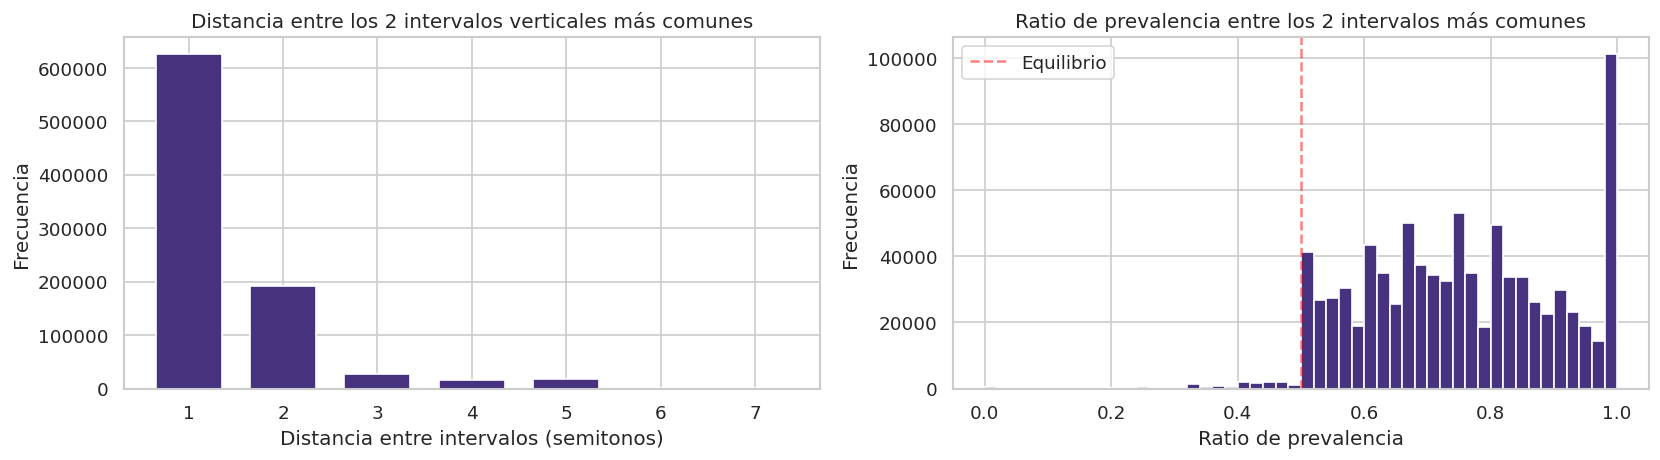


Interpretación:
  Ratio > 0.5: el intervalo más común domina claramente
  Ratio ~ 0.5: ambos intervalos son igualmente frecuentes
  Ratio < 0.5: el segundo intervalo más común es casi tan frecuente como el primero


In [19]:
# Intervalos más comunes
INTERVAL_NAMES = ['Unísono', '2da menor', '2da mayor', '3ra menor', '3ra mayor', 
                  '4ta justa', 'Tritono', '5ta justa', '6ta menor', '6ta mayor',
                  '7ma menor', '7ma mayor']

print('Distancia entre los 2 intervalos más comunes:')
print(f'  Media: {df["Distance_Between_Two_Most_Common_Vertical_Intervals"].mean():.3f}')
print(f'  Mediana: {df["Distance_Between_Two_Most_Common_Vertical_Intervals"].median():.3f}')
print(f'  Los intervalos más frecuentes están separados por ~{df["Distance_Between_Two_Most_Common_Vertical_Intervals"].mean():.1f} semitonos')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Distance_Between_Two_Most_Common_Vertical_Intervals'], 
             bins=np.arange(0.5, 8, 1), edgecolor='white', rwidth=0.7)
axes[0].set_xlabel('Distancia entre intervalos (semitonos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distancia entre los 2 intervalos verticales más comunes')
axes[0].set_xticks(range(1, 8))

axes[1].hist(df['Prevalence_Ratio_of_Two_Most_Common_Vertical_Intervals'],
             bins=50, edgecolor='white')
axes[1].set_xlabel('Ratio de prevalencia')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Ratio de prevalencia entre los 2 intervalos más comunes')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Equilibrio')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nInterpretación:')
print(f'  Ratio > 0.5: el intervalo más común domina claramente')
print(f'  Ratio ~ 0.5: ambos intervalos son igualmente frecuentes')
print(f'  Ratio < 0.5: el segundo intervalo más común es casi tan frecuente como el primero')

---
## 8. Análisis de Variabilidad Armónica

Variabilidad del número de pitch classes simultáneas:
  Media: 0.156
  Mediana: 0.000
  Máximo: 2.037


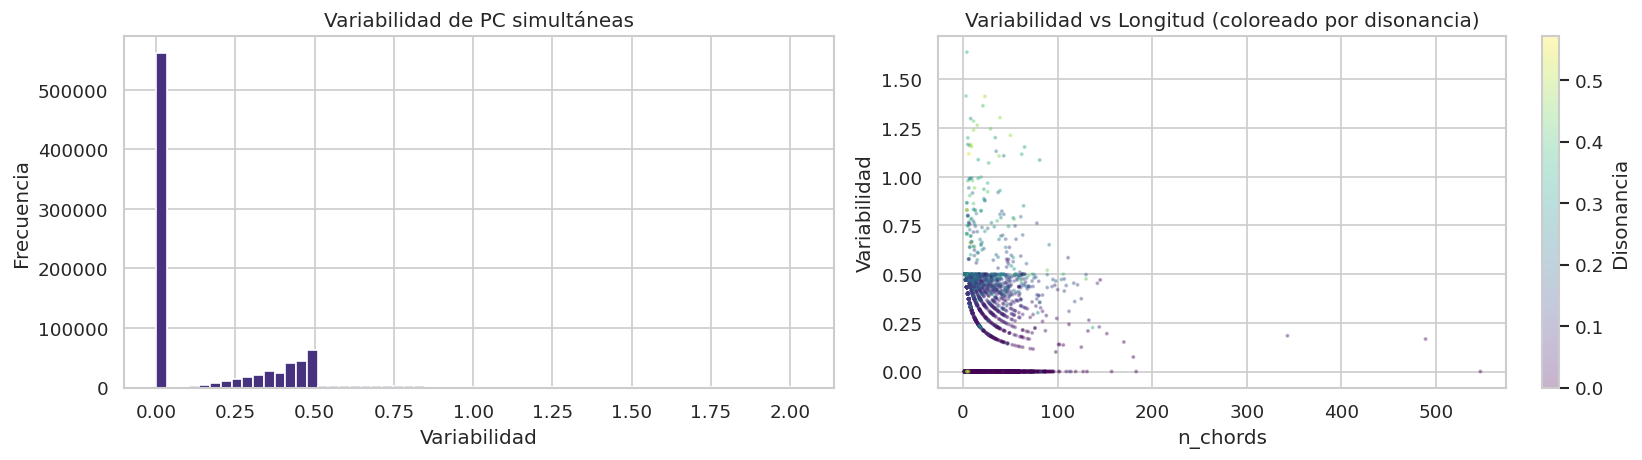


Distribución:
  Baja (0):     561855 progresiones
  Baja (<0.1):  272
  Media (0.1-0.5): 271781
  Alta (>0.5):  43446


In [20]:
print('Variabilidad del número de pitch classes simultáneas:')
print(f'  Media: {df["Variability_of_Number_of_Simultaneous_Pitch_Classes"].mean():.3f}')
print(f'  Mediana: {df["Variability_of_Number_of_Simultaneous_Pitch_Classes"].median():.3f}')
print(f'  Máximo: {df["Variability_of_Number_of_Simultaneous_Pitch_Classes"].max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Variability_of_Number_of_Simultaneous_Pitch_Classes'], 
             bins=60, edgecolor='white')
axes[0].set_xlabel('Variabilidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Variabilidad de PC simultáneas')

# Relación con longitud
scatter = axes[1].scatter(df['n_chords'].values[:5000], 
                         df['Variability_of_Number_of_Simultaneous_Pitch_Classes'].values[:5000],
                         alpha=0.3, s=2, c=df['Vertical_Dissonance_Ratio'].values[:5000], cmap='viridis')
axes[1].set_xlabel('n_chords')
axes[1].set_ylabel('Variabilidad')
axes[1].set_title('Variabilidad vs Longitud (coloreado por disonancia)')
plt.colorbar(scatter, ax=axes[1], label='Disonancia')

plt.tight_layout()
plt.show()

# Distribución de valores
print('\nDistribución:')
print('  Baja (0):    ', (df['Variability_of_Number_of_Simultaneous_Pitch_Classes'] == 0).sum(), 'progresiones')
print('  Baja (<0.1): ', (df['Variability_of_Number_of_Simultaneous_Pitch_Classes'].between(0.001, 0.1)).sum())
print('  Media (0.1-0.5):', (df['Variability_of_Number_of_Simultaneous_Pitch_Classes'].between(0.1, 0.5)).sum())
print('  Alta (>0.5): ', (df['Variability_of_Number_of_Simultaneous_Pitch_Classes'] > 0.5).sum())

---
## 9. Resumen de Conclusiones

In [21]:
print('=' * 70)
print('RESUMEN DEL ANÁLISIS DE TEORÍA MUSICAL')
print('=' * 70)

print(f'''
DATOS GENERALES
  Progresiones analizadas: {len(df):,}
  Acordes totales: {total_chords:,}
  Vocabulario armónico: {unique_chords} acordes distintos
  Longitud media de progresión: {df['n_chords'].mean():.1f} acordes

ARMONÍA
  Tipo de acorde más común: {type_counter.most_common(1)[0][0]} ({type_counter.most_common(1)[0][1]/total_chords*100:.1f}%)
  Nota fundamental más común: {root_counter.most_common(1)[0][0]} ({root_counter.most_common(1)[0][1]/total_chords*100:.1f}%)
  Densidad armónica media: {np.mean(n_pcs_per_chord):.2f} notas por acorde
  Progresiones con tríadas estándar (>80%): {(df['Standard_Triads'] > 0.8).sum():,} ({(df['Standard_Triads'] > 0.8).mean()*100:.1f}%)

DISONANCIA
  Disonancia vertical media: {df['Vertical_Dissonance_Ratio'].mean():.3f}
  Progresiones con disonancia baja (<0.1): {(df['Vertical_Dissonance_Ratio'] < 0.1).sum():,} ({(df['Vertical_Dissonance_Ratio'] < 0.1).mean()*100:.1f}%)
  Intervalos más comunes distancia media: {df['Distance_Between_Two_Most_Common_Vertical_Intervals'].mean():.2f} semitonos

COMPLEJIDAD
  Progresiones mayormente con séptimas: {(df['Seventh_Chords'] > 0.5).sum():,} ({(df['Seventh_Chords'] > 0.5).mean()*100:.1f}%)
  Progresiones complejas: {(df['Complex_Chords'] > 0.3).sum():,} ({(df['Complex_Chords'] > 0.3).mean()*100:.1f}%)
  Variabilidad armónica media: {df['Variability_of_Number_of_Simultaneous_Pitch_Classes'].mean():.3f}
''')

# Feature más importante de PCA
print(f'\nCOMPONENTES PRINCIPALES (jSymbolic features)')
print(f'  PC1 explica: {pca_feat.explained_variance_ratio_[0]*100:.1f}% de la varianza')
top_pc1 = abs(pca_feat.components_[0]).argmax()
print(f'  Feature con más peso en PC1: {FEATURE_LABELS[FEATURES[top_pc1]]}')
print(f'  Se necesitan {np.argmax(cum_var >= 0.9) + 1} componentes para explicar 90% de la varianza')

RESUMEN DEL ANÁLISIS DE TEORÍA MUSICAL

DATOS GENERALES
  Progresiones analizadas: 877,342
  Acordes totales: 23,170,138
  Vocabulario armónico: 4151 acordes distintos
  Longitud media de progresión: 26.4 acordes

ARMONÍA
  Tipo de acorde más común: Major (63.6%)
  Nota fundamental más común: G (15.8%)
  Densidad armónica media: 3.10 notas por acorde
  Progresiones con tríadas estándar (>80%): 637,317 (72.6%)

DISONANCIA
  Disonancia vertical media: 0.056
  Progresiones con disonancia baja (<0.1): 678,712 (77.4%)
  Intervalos más comunes distancia media: 1.41 semitonos

COMPLEJIDAD
  Progresiones mayormente con séptimas: 42,435 (4.8%)
  Progresiones complejas: 7,640 (0.9%)
  Variabilidad armónica media: 0.156


COMPONENTES PRINCIPALES (jSymbolic features)
  PC1 explica: 43.9% de la varianza
  Feature con más peso en PC1: Ratio de disonancia vertical
  Se necesitan 7 componentes para explicar 90% de la varianza
